<a href="https://colab.research.google.com/github/shanmugt-hub/walsh/blob/main/notebooks/capstone_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# -------------------------------------------------------
# AI-Driven Predictive KPI Forecasting
# Model Implementation Code
# -------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



In [2]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')
##df = pd.read_csv("kpi_output.csv")
df = pd.read_csv("/content/drive/MyDrive/Walsh-CS/kpi_output.csv",header=0)

df.columns = ["timestamp", "value"]
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp",inplace=True) # Set timestamp as index for time-series modeling
series = df["value"]  # Extract univariate time-series

##df['timestamp'] = pd.to_datetime(df['timestamp'])
##df = df.sort_values("timestamp")
##df = df.set_index("timestamp")

##series = df["value"]



Mounted at /content/drive


In [3]:
# -------------------------------------------------------
# Train-Test Split (80/20)
# -------------------------------------------------------

split = int(len(series) * 0.8)

train = series[:split]
test = series[split:]



In [8]:
# -------------------------------------------------------
# ARIMA MODEL
# -------------------------------------------------------

arima_model = ARIMA(train, order=(1,0,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mean_absolute_percentage_error(test, arima_forecast) * 100

print("ARIMA Results")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)



ARIMA Results
MAE: 3.195048037374082
RMSE: 4.1870014413541705
MAPE: 83.17244651316685


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [9]:
# -------------------------------------------------------
# SARIMA MODEL
# -------------------------------------------------------

sarima_model = SARIMAX(train,
                       order=(1,0,1),
                       seasonal_order=(1,1,1,24))

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = mean_absolute_percentage_error(test, sarima_forecast) * 100

print("SARIMA Results")
print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA Results
MAE: 2.993598245107376
RMSE: 3.91692323832882
MAPE: 42.25589768875279


In [11]:
# -------------------------------------------------------
# LSTM MODEL
# -------------------------------------------------------

scaler = MinMaxScaler()

scaled_series = scaler.fit_transform(series.values.reshape(-1,1))

window = 24

X = []
y = []

for i in range(window, len(scaled_series)):
    X.append(scaled_series[i-window:i])
    y.append(scaled_series[i])

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential()

model.add(LSTM(50, input_shape=(window,1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=10, batch_size=16)

lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_pred) * 100



print("LSTM Results")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0119
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0087
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0082
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0077
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0073
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0069
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0062
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
LSTM Results
MAE: 2.317520145007542
RMSE: 2.993792402315925
MAPE: 54.41658188467042


In [15]:
# -------------------------------------------------------
# HYBRID SARIMA-LSTM MODEL
# -------------------------------------------------------

# SARIMA residuals
sarima_residuals = train - sarima_fit.fittedvalues
sarima_residuals = sarima_residuals.dropna()

# Scale residuals
res_scaler = MinMaxScaler()

res_scaled = res_scaler.fit_transform(sarima_residuals.values.reshape(-1,1))

X_res = []
y_res = []

for i in range(window, len(res_scaled)):
    X_res.append(res_scaled[i-window:i])
    y_res.append(res_scaled[i])

X_res = np.array(X_res)
y_res = np.array(y_res)

hybrid_model = Sequential()

hybrid_model.add(LSTM(50, input_shape=(window,1)))
hybrid_model.add(Dense(1))

hybrid_model.compile(optimizer="adam", loss="mse")

hybrid_model.fit(X_res, y_res, epochs=10, batch_size=16)

# Residual prediction
last_window = res_scaled[-window:]

pred_residual = hybrid_model.predict(last_window.reshape(1,window,1))

pred_residual = res_scaler.inverse_transform(pred_residual)

# Align sarima_forecast with y_test_actual for evaluation
aligned_sarima_forecast = sarima_forecast.values[-len(y_test_actual):]

# Add the predicted residual (note: current implementation predicts only one residual)
hybrid_forecast = aligned_sarima_forecast + pred_residual[0]

hybrid_mae = mean_absolute_error(y_test_actual, hybrid_forecast)
hybrid_rmse = np.sqrt(mean_squared_error(y_test_actual, hybrid_forecast))
hybrid_mape = mean_absolute_percentage_error(y_test_actual, hybrid_forecast) * 100



print("Hybrid Model Results")
print("MAE:", hybrid_mae)
print("RMSE:", hybrid_rmse)
print("MAPE:", hybrid_mape)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0252
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Hybrid Model Results
MAE: 2.474948656479577
RMSE: 3.382417695084489
MAPE: 30.610352076783727


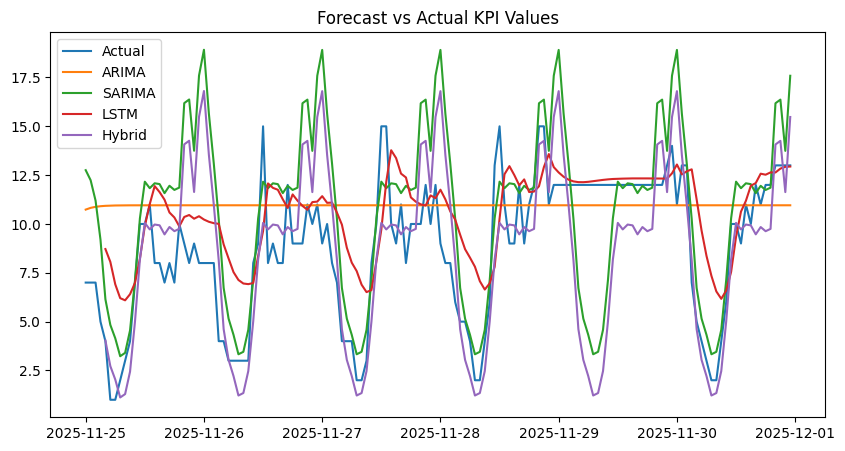

In [16]:
# -------------------------------------------------------
# Forecast Plot
# -------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.plot(test.index[-len(lstm_pred):], lstm_pred, label="LSTM")
plt.plot(test.index[-len(hybrid_forecast):], hybrid_forecast, label="Hybrid")

plt.legend()

plt.title("Forecast vs Actual KPI Values")

plt.show()

In [18]:
# -------------------------------------------------------
# Model Comparison Table
# -------------------------------------------------------

results = pd.DataFrame({
    "Model":["ARIMA","SARIMA","LSTM","Hybrid"],
    "MAE":[arima_mae, sarima_mae, lstm_mae, hybrid_mae],
    "RMSE":[arima_rmse, sarima_rmse, lstm_rmse, hybrid_rmse],
    "MAPE":[arima_mape, sarima_mape, lstm_mape, hybrid_mape]
})

print(results)

    Model       MAE      RMSE       MAPE
0   ARIMA  3.195048  4.187001  83.172447
1  SARIMA  2.993598  3.916923  42.255898
2    LSTM  2.317520  2.993792  54.416582
3  Hybrid  2.474949  3.382418  30.610352


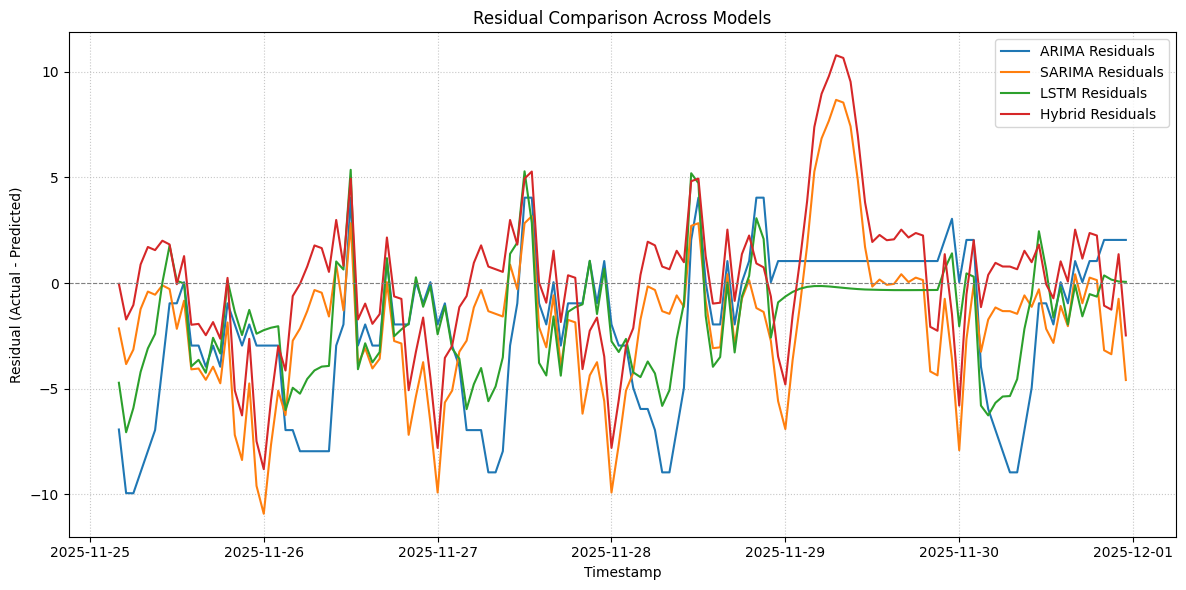

In [22]:
# -------------------------------------------------------
# Residual Comparison Plot
# -------------------------------------------------------

# Ensure all predictions and actuals are aligned to the same length (140, from LSTM's test set)
aligned_actual = y_test_actual.flatten()
aligned_arima_forecast = arima_forecast.values[-len(aligned_actual):]
aligned_sarima_forecast = sarima_forecast.values[-len(aligned_actual):]
aligned_lstm_pred = lstm_pred.flatten()
aligned_hybrid_forecast = hybrid_forecast.flatten()

# Calculate residuals for each model
arima_residuals = aligned_actual - aligned_arima_forecast
sarima_residuals = aligned_actual - aligned_sarima_forecast
lstm_residuals = aligned_actual - aligned_lstm_pred
hybrid_residuals = aligned_actual - aligned_hybrid_forecast

# Get the common time index for plotting
common_time_index = test.index[-len(aligned_actual):]

plt.figure(figsize=(12, 6))
plt.plot(common_time_index, arima_residuals, label="ARIMA Residuals")
plt.plot(common_time_index, sarima_residuals, label="SARIMA Residuals")
plt.plot(common_time_index, lstm_residuals, label="LSTM Residuals")
plt.plot(common_time_index, hybrid_residuals, label="Hybrid Residuals")

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Residual Comparison Across Models")
plt.xlabel("Timestamp")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_8661/2943644091.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')


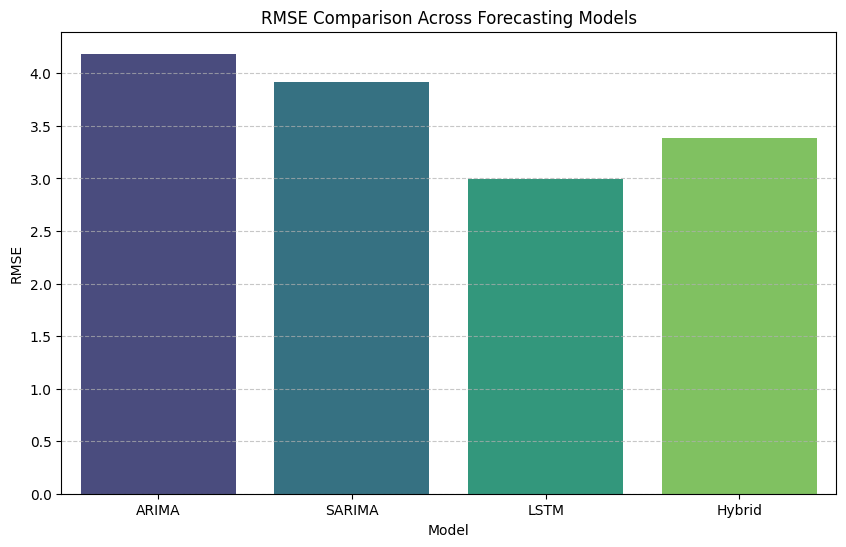

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')
plt.title('RMSE Comparison Across Forecasting Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
from scipy.stats import ttest_rel
import numpy as np # Ensure numpy is imported

print("\n==============================")
print("RQ4: Paired t-test (ARIMA vs LSTM)")
print("==============================")

alpha = 0.05 # Significance level

# Align actual values and predictions for comparison (using the period covered by LSTM predictions)
# y_test_actual has length 140, corresponding to the last 140 values of the 'test' set.
# lstm_pred has length 140.
# arima_forecast is for the entire 'test' set (length 144).

# Actual values for the period covered by LSTM predictions
actual_aligned = y_test_actual.flatten()

# ARIMA predictions aligned with the LSTM prediction period
arima_pred_aligned = arima_forecast.values[-len(actual_aligned):]

# LSTM predictions
lstm_pred_aligned = lstm_pred.flatten()

arima_error = np.abs(actual_aligned - arima_pred_aligned)
lstm_error = np.abs(actual_aligned - lstm_pred_aligned)

t_stat, p_val = ttest_rel(arima_error, lstm_error)

print("\nPaired t-test")
print("Statistic:", t_stat)
print("p-value:", p_val)

if p_val < alpha:
    print("Reject H0 \u2192 AI model (LSTM) significantly differs in error from ARIMA.")
else:
    print("Fail to reject H0 \u2192 No significant difference in error between LSTM and ARIMA.")



RQ4: Paired t-test (ARIMA vs LSTM)

Paired t-test
Statistic: 5.669538153962144
p-value: 7.967053575871349e-08
Reject H0 → AI model (LSTM) significantly differs in error from ARIMA.


In [20]:
from scipy.stats import wilcoxon

print("\n==============================")
print("RQ5: Wilcoxon Signed-Rank Test")
print("==============================")

alpha = 0.05 # Significance level

w_stat, w_p = wilcoxon(arima_error, lstm_error)

print("\nWilcoxon Test")
print("Statistic:", w_stat)
print("p-value:", w_p)

if w_p < alpha:
    print("Reject H0 \u2192 Error distributions differ significantly")
else:
    print("Fail to reject H0")



RQ5: Wilcoxon Signed-Rank Test

Wilcoxon Test
Statistic: 2519.0
p-value: 5.02227361842105e-07
Reject H0 → Error distributions differ significantly


In [21]:
print("\n==============================")
print("RQ6: Diebold–Mariano Test")
print("==============================")

# -----------------------------------------------------
# Diebold–Mariano Test Function
# -----------------------------------------------------
from scipy.stats import norm # Import norm for p-value calculation

def diebold_mariano(actual, pred1, pred2):

    e1 = actual - pred1
    e2 = actual - pred2

    d = (e1**2) - (e2**2)

    mean_d = np.mean(d)
    n = len(d)

    var_d = np.var(d, ddof=1)

    dm_stat = mean_d / np.sqrt(var_d / n)

    p_val = 2 * (1 - norm.cdf(abs(dm_stat)))

    return dm_stat, p_val

# Ensure alpha is defined for significance testing
alpha = 0.05

# Use the same aligned predictions and actual values as for t-test and Wilcoxon test
actual = actual_aligned # actual_aligned was prepared in iXked9gJT_34
arima_pred = arima_pred_aligned # arima_pred_aligned was prepared in iXked9gJT_34
lstm_pred = lstm_pred_aligned # lstm_pred_aligned was prepared in iXked9gJT_34

dm_stat, dm_p = diebold_mariano(actual, arima_pred, lstm_pred)

print("\nDiebold–Mariano Test")
print("Statistic:", dm_stat)
print("p-value:", dm_p)

if dm_p < alpha:
    print("Reject H0 \u2192 Forecast accuracy differs significantly")
else:
    print("Fail to reject H0")


print("\n==============================")
print("Statistical Validation Complete")
print("==============================")



RQ6: Diebold–Mariano Test

Diebold–Mariano Test
Statistic: 5.378968017921717
p-value: 7.491401410320009e-08
Reject H0 → Forecast accuracy differs significantly

Statistical Validation Complete
